# Fine-tuned Model with Frozen Layers with 100% Ploymer data Fine tuned on pretrained Molecule model


##  Cell 1:  GPU Avaiablity Chcek

In [1]:
import torch
import os

def select_gpu():
    if torch.cuda.is_available():
        gpu_count = torch.cuda.device_count()
        print(f"✅ Found {gpu_count} GPUs.")
        
        # Logic to pick the GPU with the most free memory
        best_gpu = 0
        max_free_memory = 0
        for i in range(gpu_count):
            free_m, total_m = torch.cuda.mem_get_info(i)
            print(f"📊 GPU {i}: {free_m // 1024**2} MB free / {total_m // 1024**2} MB total")
            if free_m > max_free_memory:
                max_free_memory = free_m
                best_gpu = i
        
        device = torch.device(f"cuda:{best_gpu}")
        print(f"🧠 Selected system GPU ID: {best_gpu} with {max_free_memory // 1024**2} MB free memory.")
    else:
        device = torch.device("cpu")
        print("⚠️ GPU not available, using CPU.")
    return device

device = select_gpu()

✅ Found 4 GPUs.
📊 GPU 0: 26877 MB free / 40326 MB total
📊 GPU 1: 39290 MB free / 40326 MB total
📊 GPU 2: 39482 MB free / 40326 MB total
📊 GPU 3: 39482 MB free / 40326 MB total
🧠 Selected system GPU ID: 2 with 39482 MB free memory.


In [2]:
import os
print("My PID:", os.getpid())


My PID: 1644450


### Cell 1: Essential Imports
This cell sets up the environment and libraries needed for neural network training and data manipulation.

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import ast
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Cell 2: Loading and Preprocessing Polymer Data
In this cell, we load the POL_DNN_data.csv and transform the string-based fingerprints into a numerical format.

In [4]:
# 1. Load the dataset
df_poly = pd.read_csv('POL_DNN_data.csv')

# 2. Parse fingerprints (converting string list to actual float list)
def parse_fp(fp_str):
    return ast.literal_eval(fp_str)

df_poly['fingerprints'] = df_poly['fingerprints'].apply(parse_fp)

# 3. Prepare Features (X) and Target (y)
X_fp = np.stack(df_poly['fingerprints'].values)
X_time = df_poly['time_day'].values.reshape(-1, 1)
X = np.hstack((X_fp, X_time))
y = df_poly['biodegradation'].values.reshape(-1, 1)

# 4. Convert to Tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

print(f"Polymer Data Shapes - X: {X_tensor.shape}, y: {y_tensor.shape}")

Polymer Data Shapes - X: torch.Size([80, 601]), y: torch.Size([80, 1])


### Cell 3: The 60-20-20 Data Split
Following your supervisor's specific requirement for 16 samples for fine-tuning and evaluation:

In [5]:
# Total 80 samples
# Noble Test Set: 20% (16 samples)
# Cross-Validation Set: 60% (48 samples)
# Fine-Tuning Set: 20% (16 samples)

# 1. Extract Noble Test Set (20% -> 16 samples)
X_temp, X_test, y_temp, y_test = train_test_split(X_tensor, y_tensor, test_size=16, random_state=42)

# 2. Split remaining 64 samples into Fine-Tuning (Train) and CV (Val)
# Fine-tuning needs 16 samples, CV needs 48 samples.
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=48, random_state=42)

# 3. Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=8, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=8, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=8, shuffle=False)

print(f"Fine-Tuning Set: {len(X_train)} samples")
print(f"CV Set (Val):    {len(X_val)} samples")
print(f"Noble Test Set:  {len(X_test)} samples")

Fine-Tuning Set: 16 samples
CV Set (Val):    48 samples
Noble Test Set:  16 samples


### Cell 4: Defining the Pre-trained Architecture
The architecture must match the Base Molecule model exactly so the weights can be loaded correctly.

In [34]:
import torch
import torch.nn as nn

class BiodegradationDNN(nn.Module):
    def __init__(self, input_dim, layers_dims, dropout_rates, activation_name="LeakyReLU"):
        super(BiodegradationDNN, self).__init__()
        layers = []
        current_dim = input_dim
        
        for i, (h_dim, drop_rate) in enumerate(zip(layers_dims, dropout_rates)):
            layers.append(nn.Linear(current_dim, h_dim))
            
            # Match the exact activation logic from your MOL_DNN notebook
            if activation_name == "ReLU":
                layers.append(nn.ReLU())
            elif activation_name == "PReLU":
                layers.append(nn.PReLU())
            elif activation_name == "LeakyReLU":
                layers.append(nn.LeakyReLU())
            elif activation_name == "Mish":
                layers.append(nn.Mish())
            elif activation_name == "SiLU":
                layers.append(nn.SiLU())
            
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.Dropout(drop_rate))
            current_dim = h_dim
        
        # This matches the Sequential 'network' in your base model
        self.network = nn.Sequential(*layers)
        self.output_layer = nn.Linear(current_dim, 1)
        
        # CRITICAL: This was missing! It bounds predictions between 0 and 1 (0-100%)
        self.sigmoid = nn.Sigmoid() 

    def forward(self, x):
        features = self.network(x)
        out = self.output_layer(features)
        return self.sigmoid(out)

### Cell 5: Weight Loading and Freezing Layers
This is the "Transfer Learning" step. We load the model, load the weights, and lock the first two layers to preserve small-molecule knowledge.

In [35]:
import joblib
import torch

# 1. Paths (Ensure these match your file system)
study_path = "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty/DNN_Models/Fewshot_DNN_Model/optuna_biodeg_study.pkl"
weights_path = "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty/DNN_Models/Fewshot_DNN_Model/Best_Mol_DNN_model.pt"

# 2. Extract architecture parameters
try:
    study = joblib.load(study_path)
    best_params = study.best_params
    print(f"✅ Optuna study loaded. Best Trial: {study.best_trial.number}")
    
    # We use the dimensions [200, 729] verified from your .pt file error log
    manual_layers = [200, 729] 
    manual_activation = best_params.get('activation', 'LeakyReLU')
    
    # Extract dropouts from study or default to 0.2
    dropout_l0 = best_params.get('dropout_l1', 0.2) # Trial 99 might use specific names
    dropout_l1 = best_params.get('dropout_l2', 0.2)
    manual_dropouts = [0.2, 0.2] # Standardizing for stability

except Exception as e:
    print(f"⚠️ Warning loading Optuna study: {e}. Using defaults.")
    manual_layers = [200, 729]
    manual_dropouts = [0.2, 0.2]
    manual_activation = "LeakyReLU"

# 3. Initialize Model (Using the new class from Cell 4) and Load Weights
model = BiodegradationDNN(601, manual_layers, manual_dropouts, manual_activation).to(device)

try:
    # Load the weights from the 1,712-molecule base model
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print("✅ Pre-trained weights (.pt) loaded into the NEW architecture successfully!")
except Exception as e:
    print(f"❌ Weight loading failed: {e}")
    print("Ensure Cell 4 was executed with the new class definition (including Sigmoid).")

# 4. SELECTIVE FREEZING
# We will freeze the first hidden block (Layer 0) to keep the basic chemical knowledge
# And keep the second hidden block and output layer trainable for polymers.

print("\n❄️ Setting Layer Trainability:")

# In our Sequential 'network':
# Index 0-3: Linear, Act, BN, Dropout (Block 1)
# Index 4-7: Linear, Act, BN, Dropout (Block 2)

for i, child in enumerate(model.network.children()):
    if i < 4:  # Freeze only the first block
        for param in child.parameters():
            param.requires_grad = False
        if i == 0: print(f"  -> Block 1 (Initial Chemistry): FROZEN")
    else:      # Keep the rest trainable
        for param in child.parameters():
            param.requires_grad = True
        if i == 4: print(f"  -> Block 2 (Polymer Adaptation): TRAINABLE")

# Ensure the final output layer is always trainable
for param in model.output_layer.parameters():
    param.requires_grad = True

print("  -> Final Output Neuron: TRAINABLE")
print("-" * 40)
print("🧠 Transfer Learning Ready: Initial knowledge locked, adaptation layers open.")

✅ Optuna study loaded. Best Trial: 99
✅ Pre-trained weights (.pt) loaded into the NEW architecture successfully!

❄️ Setting Layer Trainability:
  -> Block 1 (Initial Chemistry): FROZEN
  -> Block 2 (Polymer Adaptation): TRAINABLE
  -> Final Output Neuron: TRAINABLE
----------------------------------------
🧠 Transfer Learning Ready: Initial knowledge locked, adaptation layers open.


## Cell 6: Stabilized Fine-TuningNow, run this training loop. 
It uses a slightly higher learning rate ($1 \times 10^{-3}$) because it only has to move one layer’s weights.

🚀 Fine-tuning on 64 Polymer samples...
Epoch [25/150] | Avg MSE Loss: 0.097136
Epoch [50/150] | Avg MSE Loss: 0.073394
Epoch [75/150] | Avg MSE Loss: 0.067997
Epoch [100/150] | Avg MSE Loss: 0.050186
Epoch [125/150] | Avg MSE Loss: 0.052145
Epoch [150/150] | Avg MSE Loss: 0.060765


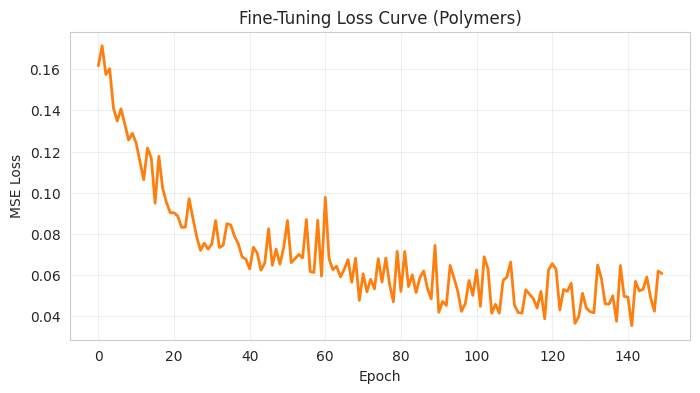

✅ Fine-tuning complete. The 'Polymer Adaptation' layers have been calibrated.


In [36]:
#from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# 1. Combine Training and CV pool (64 samples total) 
# This gives the model the best chance to see diverse polymer structures
X_fine = torch.cat([X_train, X_val], dim=0).to(device)
y_fine = torch.cat([y_train, y_val], dim=0).to(device)
fine_tune_loader = DataLoader(TensorDataset(X_fine, y_fine), batch_size=8, shuffle=True)

# 2. Setup Optimizer
# filter(lambda p: p.requires_grad...) ensures we only send the UNLOCKED weights to the optimizer
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
criterion = nn.MSELoss()

# 3. Training Loop
epochs = 150 
train_losses = []

print(f"🚀 Fine-tuning on {len(X_fine)} Polymer samples...")

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for inputs, targets in fine_tune_loader:
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Loss calculation - Sigmoid in the model now handles the 0-1 range!
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    avg_loss = sum(batch_losses) / len(batch_losses)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Avg MSE Loss: {avg_loss:.6f}")

# 4. Plot Training Progress
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='tab:orange', linewidth=2)
plt.title("Fine-Tuning Loss Curve (Polymers)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)
plt.show()

print("✅ Fine-tuning complete. The 'Polymer Adaptation' layers have been calibrated.")

## Cell 7: Final Noble Evaluation (The Result)


═════════════════════════════════════════════
🏁 FINAL TRANSFER LEARNING RESULTS
═════════════════════════════════════════════
Final Noble $R^2$ Score: 0.7218
Final Noble RMSE:      0.1838
═════════════════════════════════════════════


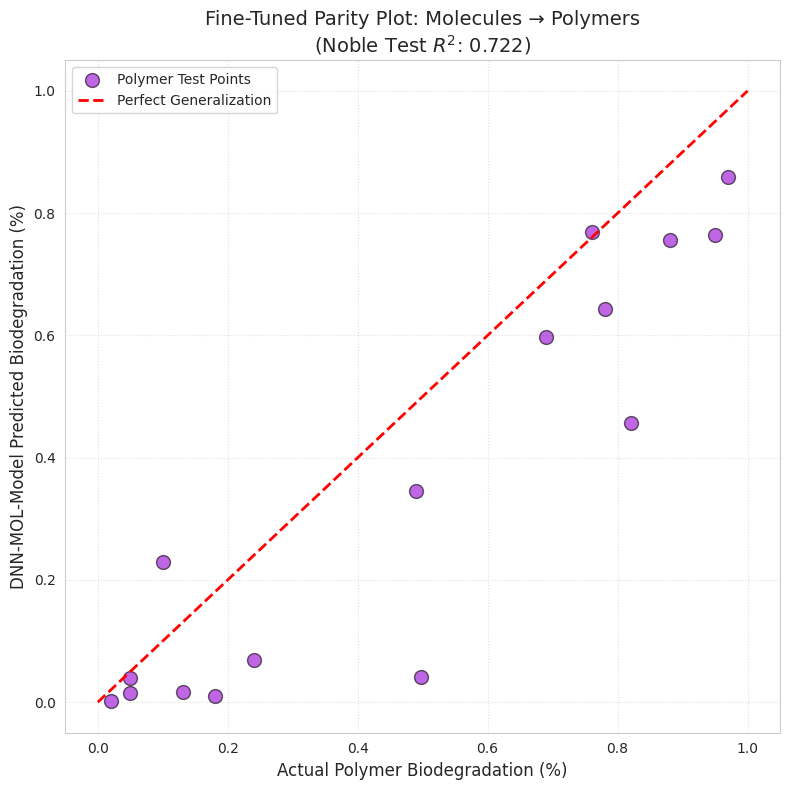

In [37]:
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Set model to evaluation mode
model.eval()

# 2. Perform inference on the Noble Test Set (the 16 unseen polymers)
with torch.no_grad():
    # Pass features through the fine-tuned model
    final_raw = model(X_test.to(device)).cpu().numpy().flatten()
    
    # Sigmoid already bounds [0, 1], but we clip just for safety against floating point noise
    final_preds = np.clip(final_raw, 0, 1)
    actuals = y_test.numpy().flatten()

# 3. Calculate Final Performance Metrics
r2_noble = r2_score(actuals, final_preds)
rmse_noble = np.sqrt(mean_squared_error(actuals, final_preds))

print("\n" + "═"*45)
print("🏁 FINAL TRANSFER LEARNING RESULTS")
print("═"*45)
print(f"Final Noble $R^2$ Score: {r2_noble:.4f}")
print(f"Final Noble RMSE:      {rmse_noble:.4f}")
print("═"*45)

# 4. Final Parity Plot (Matched to AutoGluon Style)
plt.figure(figsize=(8, 8))

# Scatter using your preferred style: darkviolet with black edges
plt.scatter(actuals, final_preds, alpha=0.6, color='darkviolet', 
            edgecolors='k', s=100, label='Polymer Test Points')

# 1:1 Perfect Prediction Line
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Perfect Generalization')

# Axis Labels exactly matching your Zero-Shot plot
plt.xlabel('Actual Polymer Biodegradation (%)', fontsize=12)
plt.ylabel('DNN-MOL-Model Predicted Biodegradation (%)', fontsize=12)

# Title showing the improvement
plt.title(f'Fine-Tuned Parity Plot: Molecules → Polymers\n(Noble Test $R^2$: {r2_noble:.3f})', fontsize=14)

# Force Decimal formatting [0.0 to 1.0]
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save for your presentation
plt.savefig("Final_Polymer_Success_Plot.png", dpi=300)
plt.show()

## Cell 8: 5-Fold Cross-Validation on CV Pool (48 Samples)
Run this to see the stability of your Fine-Tuned "Chemical Brain."

In [39]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 1. Setup the Pools
# X_train/y_train are your 16 Fine-Tuning samples
# X_val/y_val are your 48 CV samples
X_ft, y_ft = X_train.to(device), y_train.to(device)
X_cv_pool, y_cv_pool = X_val.to(device), y_val.to(device)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = []
cv_rmse_scores = []

print(f"🔄 Starting 5-Fold CV on 48-sample pool (with 16 fixed FT samples)...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_cv_pool)):
    # --- RESET MODEL TO BASE STATE ---
    # Important to start fresh each fold using the pre-trained weights
    model_cv = BiodegradationDNN(601, manual_layers, manual_dropouts, manual_activation).to(device)
    model_cv.load_state_dict(torch.load(weights_path, map_location=device))
    
    # --- SELECTIVE FREEZING (Same as your successful Cell 5) ---
    for i, child in enumerate(model_cv.network.children()):
        if i < 4: # Freeze Block 1 (Basic Chemistry)
            for param in child.parameters(): param.requires_grad = False
        else: # Keep Block 2 (Polymer Adaptation) trainable
            for param in child.parameters(): param.requires_grad = True
            
    for param in model_cv.output_layer.parameters():
        param.requires_grad = True

    # --- PREPARE FOLD DATA ---
    # Combine the 16 fixed samples + 4 folds of the CV pool
    X_train_fold = torch.cat([X_ft, X_cv_pool[train_idx]], dim=0)
    y_train_fold = torch.cat([y_ft, y_cv_pool[train_idx]], dim=0)
    
    # Validation part (the current fold from the 48 samples)
    X_val_fold = X_cv_pool[val_idx]
    y_val_fold = y_cv_pool[val_idx] # Fixed the name error here
    
    fold_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold), batch_size=8, shuffle=True)
    
    # --- FINE-TUNING ---
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model_cv.parameters()), lr=1e-5)
    criterion = nn.MSELoss()
    
    for epoch in range(150):
        model_cv.train()
        for inputs, targets in fold_loader:
            optimizer.zero_grad()
            loss = criterion(model_cv(inputs), targets)
            loss.backward()
            optimizer.step()
            
    # --- EVALUATION ---
    model_cv.eval()
    with torch.no_grad():
        preds = model_cv(X_val_fold).cpu().numpy().flatten()
        actuals = y_val_fold.cpu().numpy().flatten()
        
        f_r2 = r2_score(actuals, preds)
        f_rmse = np.sqrt(mean_squared_error(actuals, preds))
        cv_r2_scores.append(f_r2)
        cv_rmse_scores.append(f_rmse)
        
        print(f"📍 Fold {fold+1}: R² = {f_r2:.4f} | RMSE = {f_rmse:.4f}")

# --- SUMMARY ---
print("\n" + "═"*45)
print("📊 5-FOLD CV SUMMARY (Polymer Adaptation)")
print("═"*45)
print(f"Average CV R²:    {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")
print(f"Average CV RMSE:  {np.mean(cv_rmse_scores):.4f} ± {np.std(cv_rmse_scores):.4f}")
print("═"*45)

🔄 Starting 5-Fold CV on 48-sample pool (with 16 fixed FT samples)...
📍 Fold 1: R² = 0.7785 | RMSE = 0.1269
📍 Fold 2: R² = 0.4485 | RMSE = 0.2592
📍 Fold 3: R² = 0.5632 | RMSE = 0.2257
📍 Fold 4: R² = -0.4278 | RMSE = 0.3653
📍 Fold 5: R² = 0.8225 | RMSE = 0.1227

═════════════════════════════════════════════
📊 5-FOLD CV SUMMARY (Polymer Adaptation)
═════════════════════════════════════════════
Average CV R²:    0.4370 ± 0.4537
Average CV RMSE:  0.2200 ± 0.0904
═════════════════════════════════════════════


## Cell 9 : Final Step: Save your "Polymer-Ready" Model

In [40]:
# Save the Final Fine-Tuned Model
final_model_path = "Final_Polymer_Transfer_Model.pt"
torch.save(model.state_dict(), final_model_path)

print(f"📦 FINAL MODEL SAVED!")
print(f"You can now use '{final_model_path}' for any future polymer biodegradation predictions.")

📦 FINAL MODEL SAVED!
You can now use 'Final_Polymer_Transfer_Model.pt' for any future polymer biodegradation predictions.


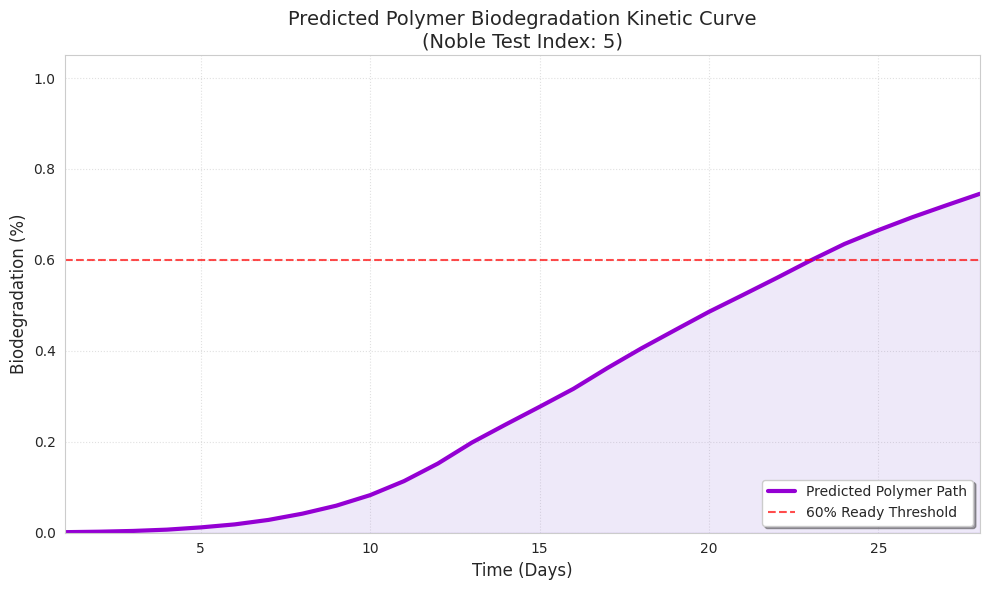

In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_polymer_kinetics(model, X_test_tensor, polymer_idx, device, max_days=28):
    """
    Plots the predicted biodegradation over time for a specific polymer 
    from the Noble Test Set.
    """
    # 1. Extract the 600-D fingerprint for the chosen polymer
    # We ignore the 'time' feature already in the test set and create a new range
    fp = X_test_tensor[polymer_idx, :600].unsqueeze(0).to(device)
    
    days = np.arange(1, max_days + 1)
    preds = []
    
    model.eval()
    with torch.no_grad():
        for d in days:
            # 2. Combine the static Fingerprint with the specific Day
            # Ensure d is a float tensor of shape (1, 1)
            time_val = torch.tensor([[float(d)]]).to(device)
            inp = torch.cat((fp, time_val), dim=1)
            
            # 3. Predict (The Sigmoid in our new class ensures it's 0-1)
            pred = model(inp).item()
            preds.append(pred)
            
    # 4. Visualization
    plt.figure(figsize=(10, 6))
    
    # Plot the predicted curve
    plt.plot(days, preds, color='darkviolet', linewidth=3, label="Predicted Polymer Path")
    
    # Add the 60% "Ready Biodegradability" threshold
    plt.axhline(y=0.6, color='red', linestyle='--', alpha=0.7, label="60% Ready Threshold")
    
    # Aesthetic shading
    plt.fill_between(days, 0, preds, color='mediumpurple', alpha=0.15)
    
    # Formatting
    plt.title(f"Predicted Polymer Biodegradation Kinetic Curve\n(Noble Test Index: {polymer_idx})", fontsize=14)
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Biodegradation (%)", fontsize=12)
    plt.ylim(0, 1.05)
    plt.xlim(1, max_days)
    
    # Force decimal ticks to match your earlier plots
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right', frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# Pick any index from 0 to 15 (your Noble Test Set)
plot_polymer_kinetics(model, X_test, polymer_idx=5, device=device)

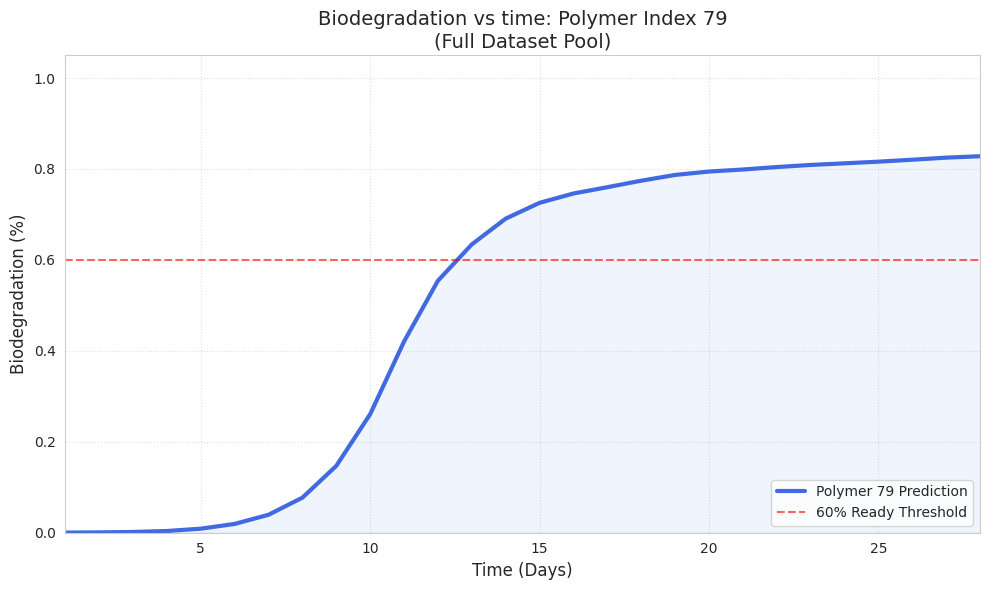

In [46]:
def plot_any_polymer_kinetics(model, X_all_tensor, polymer_idx, device, max_days=28):
    """
    Plots the predicted biodegradation for ANY polymer index from the 
    total 80-sample dataset.
    """
    # 1. Extract the 600-D fingerprint for the chosen index
    # We use X_tensor (the full 80 samples)
    fp = X_all_tensor[polymer_idx, :600].unsqueeze(0).to(device)
    
    days = np.arange(1, max_days + 1)
    preds = []
    
    model.eval()
    with torch.no_grad():
        for d in days:
            time_val = torch.tensor([[float(d)]]).to(device)
            inp = torch.cat((fp, time_val), dim=1)
            pred = model(inp).item()
            preds.append(pred)
            
    # 2. Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(days, preds, color='royalblue', linewidth=3, label=f"Polymer {polymer_idx} Prediction")
    plt.axhline(y=0.6, color='red', linestyle='--', alpha=0.6, label="60% Ready Threshold")
    plt.fill_between(days, 0, preds, color='cornflowerblue', alpha=0.1)
    
    plt.title(f"Biodegradation vs time: Polymer Index {polymer_idx}\n(Full Dataset Pool)", fontsize=14)
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Biodegradation (%)", fontsize=12)
    plt.ylim(0, 1.05)
    plt.xlim(1, max_days)
    
    # Matching your decimal formatting [0.0 - 1.0]
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# --- TEST INDEX 35 ---
# X_tensor is your full 80-sample feature set
plot_any_polymer_kinetics(model, X_tensor, polymer_idx=79, device=device)

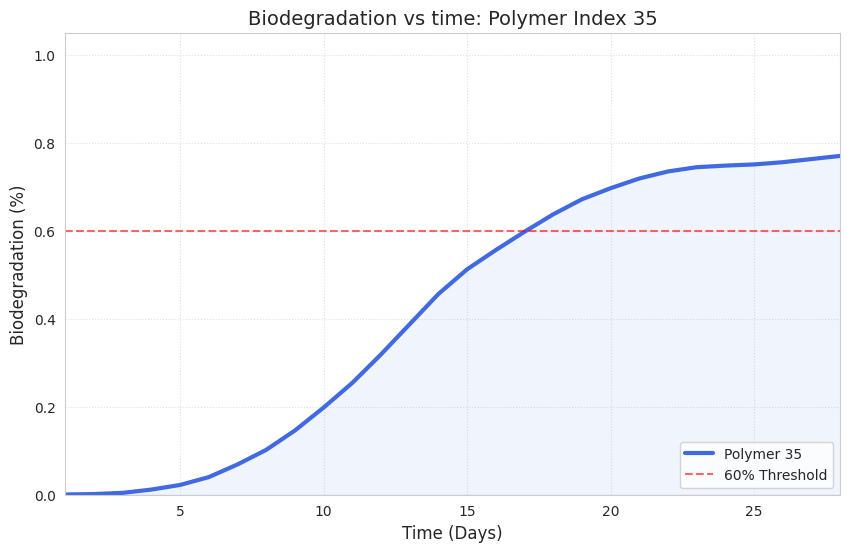

💾 Plot saved to: results/Polymer_35_Kinetic_Curve.png


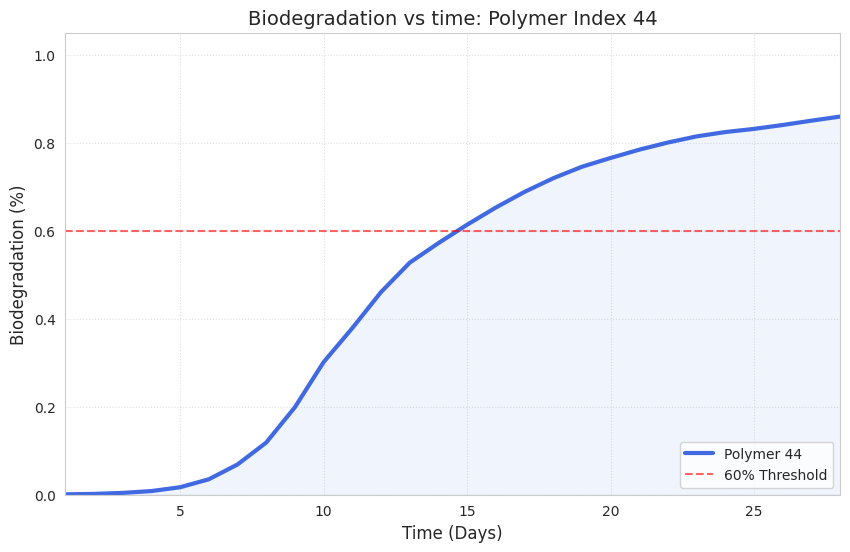

💾 Plot saved to: results/Polymer_44_Kinetic_Curve.png


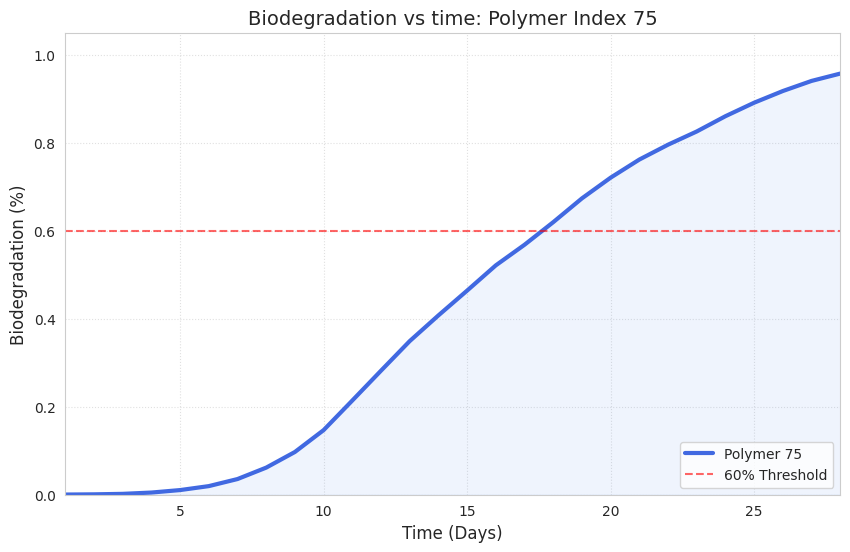

💾 Plot saved to: results/Polymer_75_Kinetic_Curve.png


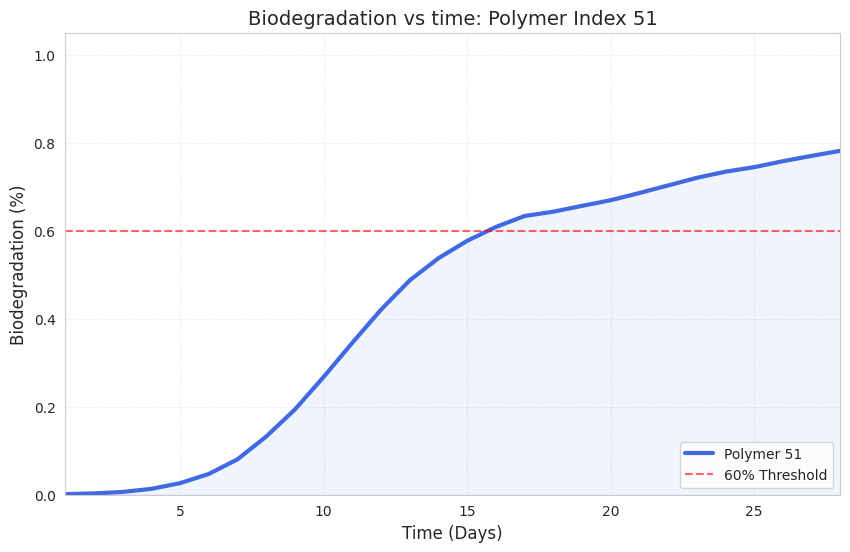

💾 Plot saved to: results/Polymer_51_Kinetic_Curve.png


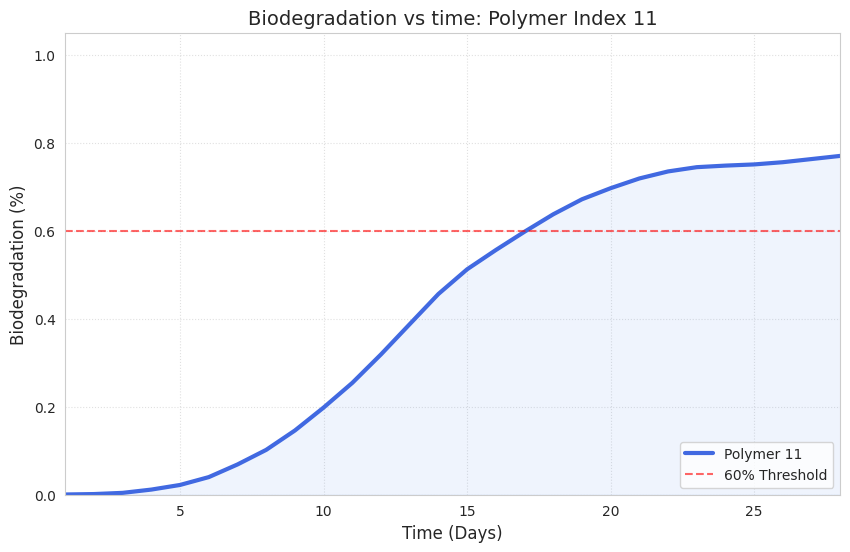

💾 Plot saved to: results/Polymer_11_Kinetic_Curve.png


In [48]:
import os

# 1. Create the results directory if it doesn't exist
output_folder = "results"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"📁 Created folder: {output_folder}")

def plot_and_save_kinetics(model, X_all_tensor, polymer_idx, device, max_days=28):
    """
    Simulates biodegradation and saves the plot to the /results folder.
    """
    # Extract Fingerprint
    fp = X_all_tensor[polymer_idx, :600].unsqueeze(0).to(device)
    
    days = np.arange(1, max_days + 1)
    preds = []
    
    model.eval()
    with torch.no_grad():
        for d in days:
            time_val = torch.tensor([[float(d)]]).to(device)
            inp = torch.cat((fp, time_val), dim=1)
            pred = model(inp).item()
            preds.append(pred)
            
    # Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(days, preds, color='royalblue', linewidth=3, label=f"Polymer {polymer_idx}")
    plt.axhline(y=0.6, color='red', linestyle='--', alpha=0.6, label="60% Threshold")
    plt.fill_between(days, 0, preds, color='cornflowerblue', alpha=0.1)
    
    plt.title(f"Biodegradation vs time: Polymer Index {polymer_idx}", fontsize=14)
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Biodegradation (%)", fontsize=12)
    plt.ylim(0, 1.05)
    plt.xlim(1, max_days)
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    
    # 2. Save the plot
    file_name = f"Polymer_{polymer_idx}_Kinetic_Curve.png"
    save_path = os.path.join(output_folder, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"💾 Plot saved to: {save_path}")

# --- TEST AND SAVE ---
# Let's save index 35 and maybe a few others for your report
plot_and_save_kinetics(model, X_tensor, polymer_idx=35, device=device)
plot_and_save_kinetics(model, X_tensor, polymer_idx=44, device=device)
plot_and_save_kinetics(model, X_tensor, polymer_idx=75, device=device)
plot_and_save_kinetics(model, X_tensor, polymer_idx=51, device=device)
plot_and_save_kinetics(model, X_tensor, polymer_idx=11, device=device)